In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE

import joblib

In [3]:
df = pd.read_csv("../data/processed/creditcard_processed.csv")
df.duplicated().sum()

np.int64(0)

In [4]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64


In [6]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample( # type: ignore
    X_train,
    y_train
)
print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


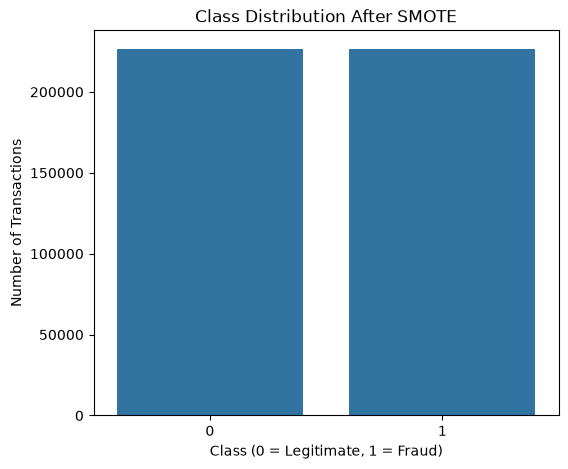

In [7]:
plt.figure(figsize=(6, 5))

sns.countplot(
    x=y_train_smote # type: ignore
)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

In [8]:
model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42,
    verbose=1
)

In [9]:
model.fit(
    X_train_smote,
    y_train_smote
)

      Iter       Train Loss   Remaining Time 
         1           1.2189           16.37m
         2           1.0814           14.98m
         3           0.9666           14.34m
         4           0.8696           13.62m
         5           0.7857           13.14m
         6           0.7143           12.80m
         7           0.6523           12.51m
         8           0.5967           12.27m
         9           0.5488           12.04m
        10           0.5062           12.02m
        20           0.2678           11.39m
        30           0.1768           10.11m
        40           0.1385            8.76m
        50           0.1144            7.33m
        60           0.0982            5.82m
        70           0.0873            4.36m
        80           0.0784            2.91m
        90           0.0705            1.45m
       100           0.0637            0.00s


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: int, default=0Enable verbose output. If 1 then it prints progress and performanceonce in a while (the more trees the lower the frequency). If greaterthan 1 then it prints progress and performance for every tree.Values must be in the range `[0, inf)`.",1
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3


In [10]:
y_proba = model.predict_proba(X_test)[:, 1]


In [11]:
threshold = 0.5

y_pred = (y_proba >= threshold).astype(int)

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.20      0.83      0.32        95

    accuracy                           0.99     56746
   macro avg       0.60      0.91      0.66     56746
weighted avg       1.00      0.99      1.00     56746



In [13]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_proba)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

Precision: 0.1951
Recall:    0.8316
F1-score:  0.3160
PR-AUC:    0.7242


In [14]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 56325
False Positives: 326
False Negatives: 16
True Positives  : 79


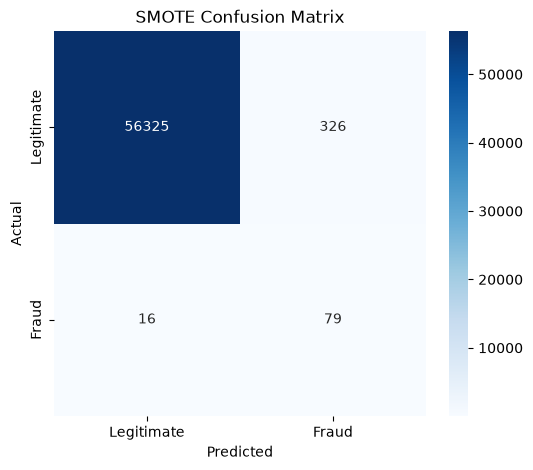

In [15]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SMOTE Confusion Matrix")

plt.show()

In [16]:
pr_auc = average_precision_score(y_test, y_proba)

print(f"PR-AUC: {pr_auc:.4f}")

PR-AUC: 0.7242


In [17]:
joblib.dump(
    model,
    "../models/smote_model.pkl"
)

print("SMOTE model saved successfully.")

SMOTE model saved successfully.
